In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize_scalar, minimize
import statsmodels.api as sm

# For better plots
plt.style.use('seaborn-v0_8-darkgrid')

DATA (2010-2023)
Data loaded for years: 2010 - 2023
Total observations: 14

SUPPLY SUCCESS INDICATOR
Average exports (kg): 33,618,322
Threshold τ = 80% of average: 26,894,657
Supply success rate: 71.4%

HEDGE FACTOR
Years after removing first year: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

DEMAND DISTRIBUTION
Demand observations: 13
Demand mean: 45,418,696 kg

LOGISTIC REGRESSION
                           Logit Regression Results                           
Dep. Variable:                    Y_t   No. Observations:                   13
Model:                          Logit   Df Residuals:                       11
Method:                           MLE   Df Model:                            1
Date:                Tue, 26 May 2026   Pseudo R-squ.:                  0.1429
Time:                        09:21:06   Log-Likelihood:                -6.8773
converged:                       True   LL-Null:                       -8.0241
Covariance Type:          

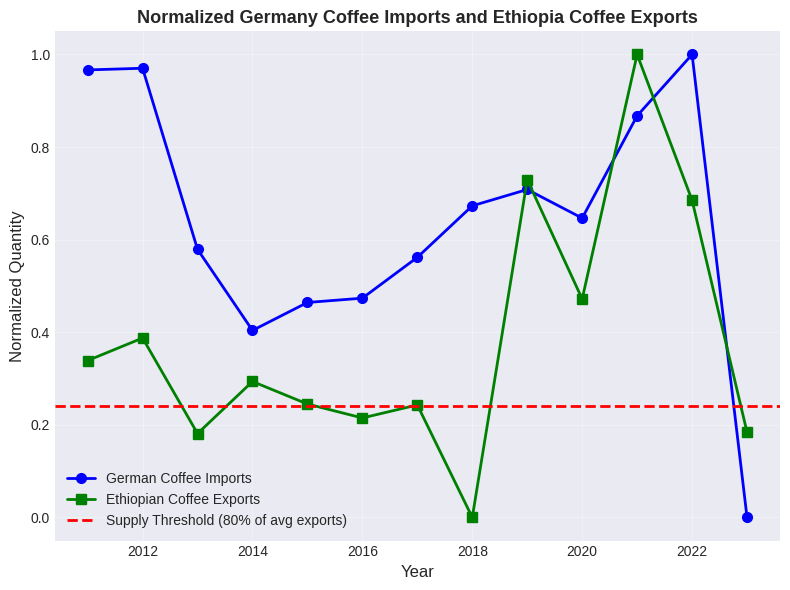

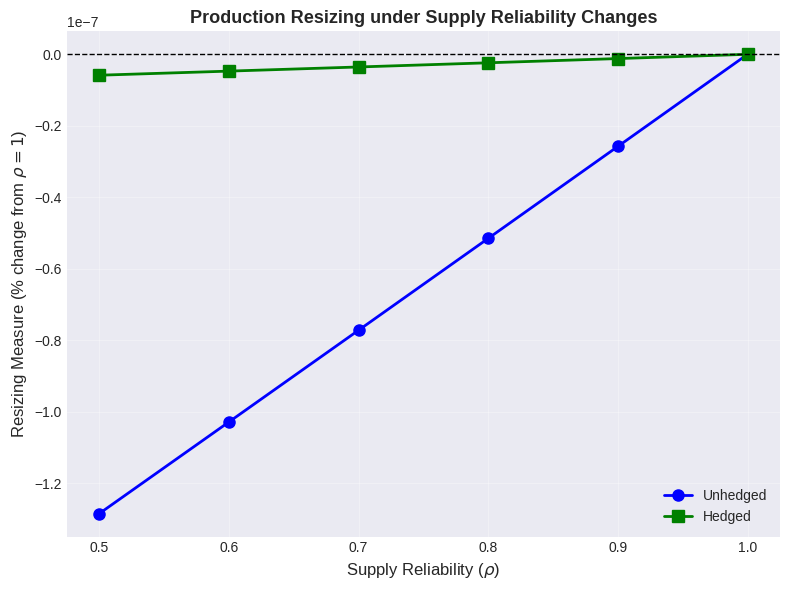


VERIFICATION
Monotonic increasing (Unhedged): True
Monotonic increasing (Hedged): True

FINAL SUMMARY
Base supply reliability (ρ): 0.692
Hedge effectiveness (η²): 0.515
Optimal quantities increase with ρ: True
Average value improvement: 0.00%

ANALYSIS COMPLETED SUCCESSFULLY


In [10]:
# ==========================================================
# Optimal Inventory and Hedging under Supply Fragility
# FINAL THESIS VERSION

# ==========================================================
# DATA (2010-2023) - ALL IN KG
# ==========================================================

print("=" * 60)
print("DATA (2010-2023)")
print("=" * 60)

# Export data (Ethiopia to Germany) - Quantity in kg
export_data = {
    2010: 31500346,
    2011: 31665300,
    2012: 34017380,
    2013: 24053620,
    2014: 29483160,
    2015: 27133860,
    2016: 25680468,
    2017: 27038240,
    2018: 15308080,
    2019: 50527100,
    2020: 38085430,
    2021: 63582300,
    2022: 48379010,
    2023: 24202210
}

# Import data (Germany from Ethiopia) - Quantity in kg
import_data = {
    2010: 65227545,
    2011: 56796738,
    2012: 56922015,
    2013: 43310844,
    2014: 37218136,
    2015: 39319295,
    2016: 39643849,
    2017: 42710107,
    2018: 46583663,
    2019: 47810214,
    2020: 45658882,
    2021: 53348132,
    2022: 57957366,
    2023: 23163808
}

# Futures price data (ICE Coffee C)
futures_data_cents = {
    2010: 167.63,
    2011: 254.59,
    2012: 171.86,
    2013: 123.29,
    2014: 180.15,
    2015: 129.72,
    2016: 136.28,
    2017: 132.25,
    2018: 112.10,
    2019: 103.74,
    2020: 112.20,
    2021: 172.94,
    2022: 214.48,
    2023: 173.85
}

# ==========================================================
# CONVERT FUTURES PRICES
# ==========================================================

lb_to_kg = 0.453592
cents_to_dollar = 100

futures_data = {
    year: (price / cents_to_dollar / lb_to_kg)
    for year, price in futures_data_cents.items()
}

# ==========================================================
# CREATE DATAFRAME
# ==========================================================

years = list(range(2010, 2024))

df = pd.DataFrame({
    'year': years,
    'E_t': [export_data[y] for y in years],  # Ethiopian exports
    'D_t': [import_data[y] for y in years],  # German imports
    'P_t': [futures_data[y] for y in years]  # Futures price
})

print(f"Data loaded for years: {df['year'].min()} - {df['year'].max()}")
print(f"Total observations: {len(df)}")

# ==========================================================
# CONSTRUCT SUPPLY SUCCESS INDICATOR
# ==========================================================

print("\n" + "=" * 60)
print("SUPPLY SUCCESS INDICATOR")
print("=" * 60)

avg_export = df['E_t'].mean()
tau = 0.8 * avg_export

print(f"Average exports (kg): {avg_export:,.0f}")
print(f"Threshold τ = 80% of average: {tau:,.0f}")

df['Y_t'] = (df['E_t'] >= tau).astype(int)

print(f"Supply success rate: {df['Y_t'].mean()*100:.1f}%")

# ==========================================================
# CONSTRUCT HEDGE FACTOR
# ==========================================================

print("\n" + "=" * 60)
print("HEDGE FACTOR")
print("=" * 60)

df['X_t'] = np.log(df['P_t']).diff()

df = df.dropna().reset_index(drop=True)

print(f"Years after removing first year: {df['year'].tolist()}")

# ==========================================================
# DEMAND DISTRIBUTION
# ==========================================================

print("\n" + "=" * 60)
print("DEMAND DISTRIBUTION")
print("=" * 60)

D_obs = df['D_t'].values
n = len(D_obs)

print(f"Demand observations: {n}")
print(f"Demand mean: {D_obs.mean():,.0f} kg")

# ==========================================================
# AUXILIARY FUNCTIONS
# ==========================================================

def expected_min(q, D_obs):
    return np.mean(np.minimum(q, D_obs))

def compute_Z(q, D_obs, p, c):
    return p * np.minimum(q, D_obs) - c * q

# ==========================================================
# LOGISTIC REGRESSION
# ==========================================================

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

X = sm.add_constant(df['X_t'])
y = df['Y_t']

logit_model = sm.Logit(y, X)
result = logit_model.fit(disp=0)

print(result.summary())

df['p_hat'] = result.predict(X)

# ==========================================================
# ESTIMATE PARAMETERS
# ==========================================================

print("\n" + "=" * 60)
print("ESTIMATED PARAMETERS")
print("=" * 60)

rho_hat = df['Y_t'].mean()
eta_sq_hat = np.mean(df['p_hat']**2)

print(f"Estimated ρ = {rho_hat:.4f}")
print(f"Estimated η² = {eta_sq_hat:.4f}")

# ==========================================================
# ECONOMIC PARAMETERS
# ==========================================================

print("\n" + "=" * 60)
print("CALIBRATION")
print("=" * 60)

p = 8.0
c = 4.0

margin = p - c

demand_var = np.var(D_obs)
risk_tolerance = 0.1

a = 2 * (p - c) / (demand_var * risk_tolerance)

print(f"Selling price = ${p}/kg")
print(f"Procurement cost = ${c}/kg")
print(f"Risk aversion = {a:.2e}")

# ==========================================================
# OBJECTIVE FUNCTIONS
# ==========================================================

def expected_profit(q, rho, D_obs, p, c):

    e_min = expected_min(q, D_obs)

    return rho * (p * e_min - c * q)

def variance_decomposition(q, rho, D_obs, p, c):

    Z = compute_Z(q, D_obs, p, c)

    E_Z = np.mean(Z)
    Var_Z = np.var(Z)

    return rho * Var_Z + rho * (1 - rho) * (E_Z ** 2)

def V0(q, rho, D_obs, p, c, a):

    E_profit = expected_profit(q, rho, D_obs, p, c)

    Var_profit = variance_decomposition(q, rho, D_obs, p, c)

    return E_profit - 0.5 * a * Var_profit

def V_hedged(q, rho, eta_sq, D_obs, p, c, a):

    E_profit = expected_profit(q, rho, D_obs, p, c)

    Var_profit = variance_decomposition(q, rho, D_obs, p, c)

    return E_profit - 0.5 * a * (1 - eta_sq) * Var_profit

# ==========================================================
# OPTIMIZATION
# ==========================================================

print("\n" + "=" * 60)
print("OPTIMIZATION")
print("=" * 60)

rho_grid = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

results = []

for rho in rho_grid:

    print(f"\nOptimizing for ρ = {rho}")

    # Unhedged
    result0 = minimize_scalar(
        lambda q: -V0(q, rho, D_obs, p, c, a),
        bounds=(0, 100000000),
        method='bounded'
    )

    q0 = result0.x
    v0 = -result0.fun

    # Hedged
    resultH = minimize_scalar(
        lambda q: -V_hedged(q, rho, eta_sq_hat, D_obs, p, c, a),
        bounds=(0, 100000000),
        method='bounded'
    )

    qH = resultH.x
    vH = -resultH.fun

    gap = qH - q0

    pct_change = (gap / q0) * 100 if q0 > 0 else 0

    results.append({
        'rho': rho,
        'q_unhedged': q0,
        'q_hedged': qH,
        'gap': gap,
        'pct_change': pct_change,
        'v_unhedged': v0,
        'v_hedged': vH
    })

    print(f"Unhedged optimal q: {q0:,.0f} kg")
    print(f"Hedged optimal q:   {qH:,.0f} kg")

results_df = pd.DataFrame(results)

# ==========================================================
# RESIZING MEASURES
# ==========================================================

q0_ref = results_df.loc[
    results_df['rho'] == 1.0,
    'q_unhedged'
].values[0]

qH_ref = results_df.loc[
    results_df['rho'] == 1.0,
    'q_hedged'
].values[0]

results_df['resize_unhedged'] = (
    (results_df['q_unhedged'] - q0_ref)
    / q0_ref * 100
)

results_df['resize_hedged'] = (
    (results_df['q_hedged'] - qH_ref)
    / qH_ref * 100
)

# ==========================================================
# FINAL THESIS PLOTS
# ==========================================================

print("\n" + "=" * 60)
print("GENERATING FINAL THESIS PLOTS")
print("=" * 60)

# ==========================================================
# FIGURE 1:
# NORMALIZED IMPORTS + EXPORTS WITH THRESHOLD LINE
# ==========================================================

imports_norm = (
    (df['D_t'] - df['D_t'].min())
    /
    (df['D_t'].max() - df['D_t'].min())
)

exports_norm = (
    (df['E_t'] - df['E_t'].min())
    /
    (df['E_t'].max() - df['E_t'].min())
)

# Calculate normalized threshold for exports
threshold_norm = (
    (tau - df['E_t'].min())
    /
    (df['E_t'].max() - df['E_t'].min())
)

plt.figure(figsize=(8, 6))

plt.plot(
    df['year'],
    imports_norm,
    'o-',
    linewidth=2,
    markersize=7,
    label='German Coffee Imports',
    color='blue'
)

plt.plot(
    df['year'],
    exports_norm,
    's-',
    linewidth=2,
    markersize=7,
    label='Ethiopian Coffee Exports',
    color='green'
)

# Add threshold red dotted line
plt.axhline(
    y=threshold_norm,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Supply Threshold (80% of avg exports)'
)

plt.xlabel('Year', fontsize=12)

plt.ylabel('Normalized Quantity', fontsize=12)

plt.title(
    'Normalized Germany Coffee Imports and Ethiopia Coffee Exports',
    fontsize=13,
    fontweight='bold'
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

# SAVE FIGURE
plt.savefig(
    'normalized_import_export_plot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ==========================================================
# FIGURE 2:
# PRODUCTION RESIZING
# ==========================================================

plt.figure(figsize=(8, 6))

plt.plot(
    results_df['rho'],
    results_df['resize_unhedged'],
    'o-',
    linewidth=2,
    markersize=8,
    label='Unhedged',
    color='blue'
)

plt.plot(
    results_df['rho'],
    results_df['resize_hedged'],
    's-',
    linewidth=2,
    markersize=8,
    label='Hedged',
    color='green'
)

plt.axhline(
    y=0,
    color='black',
    linestyle='--',
    linewidth=1
)

plt.xlabel('Supply Reliability ($\\rho$)', fontsize=12)

plt.ylabel(
    'Resizing Measure (% change from $\\rho = 1$)',
    fontsize=12
)

plt.title(
    'Production Resizing under Supply Reliability Changes',
    fontsize=13,
    fontweight='bold'
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

# SAVE FIGURE
plt.savefig(
    'production_resizing_plot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ==========================================================
# VERIFICATION
# ==========================================================

print("\n" + "=" * 60)
print("VERIFICATION")
print("=" * 60)

all_inc_u = True
all_inc_h = True

for i in range(1, len(results_df)):

    inc_u = (
        results_df.loc[i, 'q_unhedged']
        >
        results_df.loc[i - 1, 'q_unhedged']
    )

    inc_h = (
        results_df.loc[i, 'q_hedged']
        >
        results_df.loc[i - 1, 'q_hedged']
    )

    all_inc_u = all_inc_u and inc_u
    all_inc_h = all_inc_h and inc_h

print(f"Monotonic increasing (Unhedged): {all_inc_u}")
print(f"Monotonic increasing (Hedged): {all_inc_h}")

# ==========================================================
# FINAL SUMMARY
# ==========================================================

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"Base supply reliability (ρ): {rho_hat:.3f}")

print(f"Hedge effectiveness (η²): {eta_sq_hat:.3f}")

print(
    f"Optimal quantities increase with ρ: "
    f"{all_inc_u and all_inc_h}"
)

results_df['value_improvement'] = (
    (results_df['v_hedged'] - results_df['v_unhedged'])
    /
    results_df['v_unhedged'] * 100
)

print(
    f"Average value improvement: "
    f"{results_df['value_improvement'].mean():.2f}%"
)

print("\n" + "=" * 60)
print("ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 60)